# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Sandi Suryo Nugroho | 5054251020 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
(https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [20]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.drop('customerID', axis=1)

print("Dimensi Data:", df.shape)
df.info()
display(df.describe())
print(f"Jumlah Missing Value: {df.isnull().sum().sum()}")

Dimensi Data: (7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod    

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Jumlah Missing Value: 11


C:\Users\Axioo Pongo\AppData\Local\Temp\ipykernel_19620\1597260454.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


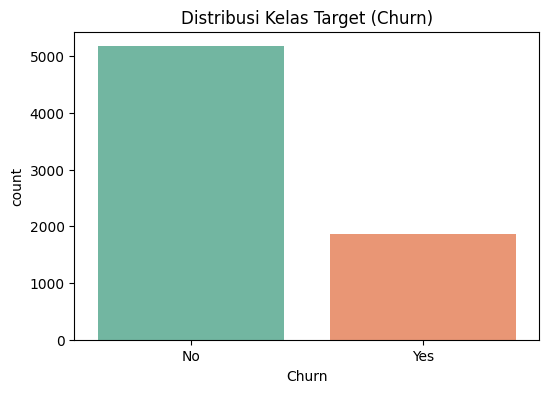

Persentase Kelas Target:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [21]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Churn)')
plt.show()

print("Persentase Kelas Target:")
print(df['Churn'].value_counts(normalize=True) * 100)

C:\Users\Axioo Pongo\AppData\Local\Temp\ipykernel_19620\2309600212.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\Axioo Pongo\AppData\Local\Temp\ipykernel_19620\2309600212.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\Axioo Pongo\AppData\Local\Temp\ipykernel_19620\2309600212.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2')


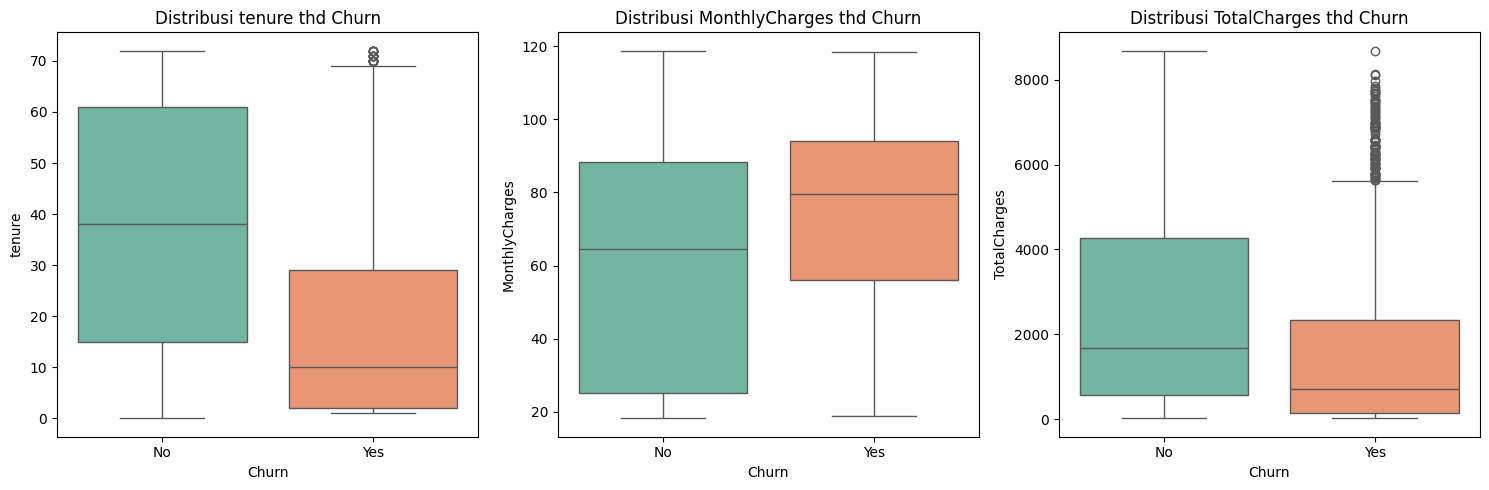

In [22]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
numerics = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(numerics):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribusi {col} thd Churn')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [23]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Karena missing value pada TotalCharges sangat sedikit (hanya 11 baris dari 7043), kita bisa mendropnya
df = df.dropna()
print("Sisa baris setelah hapus missing values:", df.shape[0])

Sisa baris setelah hapus missing values: 7032


In [24]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
X_raw = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

X = pd.get_dummies(X_raw, drop_first=True)
print("Jumlah fitur setelah encoding:", X.shape[1])

Jumlah fitur setelah encoding: 30


In [25]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)

Ukuran X_train: (5625, 30)
Ukuran X_test: (1407, 30)


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [26]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [27]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=300, random_state=42)
mlp_base.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [28]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_base = mlp_base.predict(X_test_scaled)
print("Akurasi Baseline:", accuracy_score(y_test, y_pred_base))

Akurasi Baseline: 0.7917555081734187


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [29]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
activations = ['relu', 'tanh', 'logistic']
act_results = []


In [30]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.

for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=300, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    act_results.append({'Activation': act, 'Accuracy': acc})
    
df_act = pd.DataFrame(act_results)
display(df_act.sort_values(by='Accuracy', ascending=False))

c:\Users\Axioo Pongo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Axioo Pongo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,Activation,Accuracy
0,relu,0.791756
1,tanh,0.790334
2,logistic,0.788913


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [31]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
architectures = [(2,), (5,), (10,), (50,), (100, 50)]
arch_names = ['(2)', '(5)', '(10)', '(50)', '(100, 50)']
train_acc = []
test_acc = []

In [32]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
best_act = 'relu'

for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, activation=best_act, max_iter=300, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_acc.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test_scaled)))

c:\Users\Axioo Pongo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


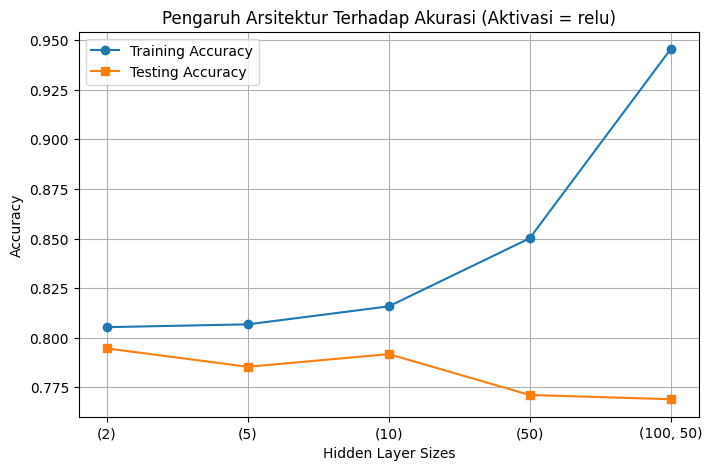

In [33]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8, 5))
plt.plot(arch_names, train_acc, marker='o', label='Training Accuracy')
plt.plot(arch_names, test_acc, marker='s', label='Testing Accuracy')
plt.title(f'Pengaruh Arsitektur Terhadap Akurasi (Aktivasi = {best_act})')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [40]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
best_model = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=300, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

metrics = pd.DataFrame([{
    'Model': 'Best ANN (10,) relu',
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best),
    'Recall': recall_score(y_test, y_pred_best),
    'F1-Score': f1_score(y_test, y_pred_best)
}])
display(metrics)

,Model,Accuracy,Precision,Recall,F1-Score
0,"Best ANN (10,) relu",0.791756,0.620178,0.558824,0.587904


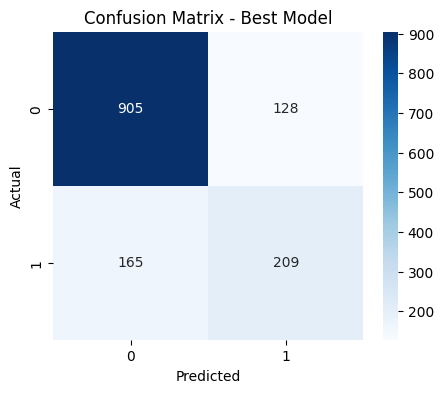

In [41]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

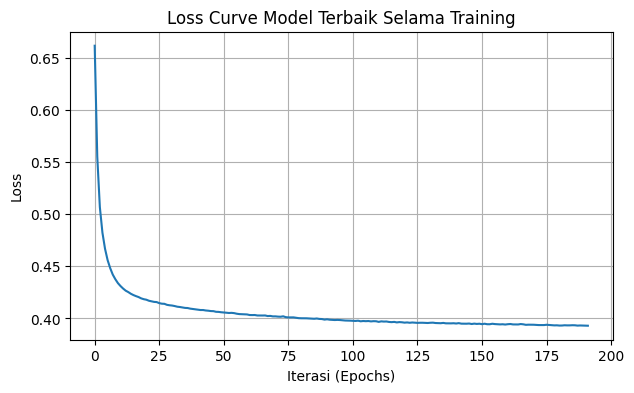

In [42]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(7, 4))
plt.plot(best_model.loss_curve_)
plt.title('Loss Curve Model Terbaik Selama Training')
plt.xlabel('Iterasi (Epochs)')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 5. Analisis

Dengan menggunakan arsitektur dasar yaitu 1 *hidden layer* berisi 10 neuron (`hidden_layer_sizes=(10,)`), dilakukan perbandingan tiga fungsi aktivasi. Hasil akurasi pada data uji menunjukkan fungsi `relu` (79,18%) unggul dibandingkan `tanh` (79,03%) dan `logistic` (78,89%).

### Model Terbaik
Model ANN dengan arsitektur `(10,)` dan aktivasi ReLU memberikan performa pengujian tertinggi dengan akurasi 79,17%.

### Terjadi Overfitting
Menggunakan arsitektur yang lebih kompleks (seperti layer 50 atau 100, 50) justru membuat model terjebak *overfitting*, yaitu sekadar menghafal data latih namun kinerjanya menurun pada data uji.


### Kelemahan pada Kelas Minoritas
Meski akurasi keseluruhannya tinggi, Confusion Matrix menunjukkan model masih kesulitan mendeteksi pelanggan yang benar-benar churn (kelas 1). Hal ini terlihat dari banyaknya kegagalan deteksi (False Negative) yang menyebabkan nilai Recall cukup rendah di angka 55,88%.

Kurva loss menunjukkan bahwa model berhasil belajar secara stabil dan mencapai titik konvergen di nilai kerugian sekitar 0.40.


# 6. Kesimpulan dan Saran


### **Kesimpulan:**

Fungsi aktivasi **ReLU** memberikan hasil performa yang paling optimal untuk dataset ini dibandingkan fungsi *Tanh* maupun *Logistic/Sigmoid*.

Model terbaik yang dievaluasi pada akhir eksperimen adalah **ANN dengan arsitektur (10,) dan aktivasi ReLU**.

Model terbaik tersebut menghasilkan metrik evaluasi pada data uji sebagai berikut:


* **Accuracy (Akurasi):** 79,17%


* **Precision:** 62,01%


* **Recall:** 55,88%


* **F1-Score:** 58,79%



Perbedaan yang cukup jauh antara nilai Akurasi (79%) dengan nilai Precision, Recall, dan F1-Score (55-62%) merupakan akibat langsung dari imbalanced dataset. Model cukup akurat secara keseluruhan, namun masih cukup kesulitan dalam mendeteksi dengan tepat pelanggan mana yang benar-benar akan churn.

### **Saran**

Mungkin untuk selanjutnya, belajar dari case ini, bisa dilakukan Handling terhadap class imbalance (dengan oversampling/SMOTE) tersebut agar model dapat memprediksi dengan lebih optimal dan akurat